# ESERCITAZIONE 4

In [148]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import loggamma

In [149]:
def poisson_pdf(t, tau):
    return (np.exp(-t/tau)) / tau

In [150]:
def gaussian_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

In [151]:
def log_likelihood_normal(N, dati):
    return (loggamma(N-1)-(N-1)*np.log(np.sum(dati)))

In [152]:
def plot_poisson(titolo, dati, tau, bins=80):


# calcolo istogramma senza disegnare subito
    h, bin_edges = np.histogram(dati, bins=80, range=(0, np.max(dati)))
    delta_x = bin_edges[1] - bin_edges[0]
    centri = (bin_edges[:-1] + bin_edges[1:]) / 2
    # disegno istogramma
    plt.bar(centri, h, width=delta_x, color='blue',  alpha=0.6, label='Dati')
    # barre di errore Poisson
    plt.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2,
                    fmt='none', color='grey', lw=1, label='Errore Standard')

        # curva normale standard (PDF moltiplicata per n*Δx)
    plt.plot(centri, poisson_pdf(centri, tau)*len(dati)*delta_x,
                color='red', label='Normale standard')

    plt.legend(fontsize=8)
    plt.xlabel('Tempi [s]')
    plt.ylabel('Frequenza')
    plt.title(f'Istogramma con curva')
    plt.show()

In [153]:
def plot_gaussiana(titolo, dati, media, varianza):

    h, bin_edges = np.histogram(dati, bins=80, range=(media - 4*np.sqrt(varianza), media + 4*np.sqrt(varianza)))
    delta_x = bin_edges[1] - bin_edges[0]
    centri = (bin_edges[:-1] + bin_edges[1:]) / 2
    # disegno istogramma
    plt.bar(centri, h, width=delta_x, color='blue',  alpha=0.6, label='Dati')
    # barre di errore Poisson
    plt.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2,
                    fmt='none', color='grey', lw=1, label='Errore Standard')

        # curva normale standard (PDF moltiplicata per n*Δx)
    plt.plot(centri, gaussian_pdf(centri, media, np.sqrt(varianza)) *len(dati)*delta_x ,
                color='red', label='Normale standard')

    plt.legend(fontsize=8)
    plt.xlabel('Tempi [s]')
    plt.ylabel('Frequenza')
    plt.title(f'Istogramma con curva')

In [154]:
def log_likelihood(dati, tau):
    N = len(dati)
    return - N * np.log(tau) - np.sum(dati) / tau

### LETTURA DATI

Text(0.5, 1.0, 'Istogramma dei dati')

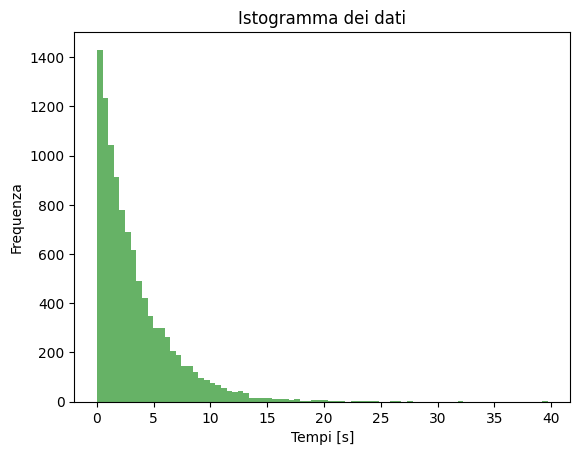

In [155]:
dati = np.loadtxt("dati/gruppo1.txt")
dati = dati / 1000

plt.hist(dati, bins=80, density=False, alpha=0.6, color='g')
plt.xlabel('Tempi [s]')
plt.ylabel('Frequenza')
plt.title('Istogramma dei dati')


### CALCOLO PARAMETRI

In [156]:
stima_tau=np.sum(dati)/len(dati)
print(f"Stima di tau: {stima_tau}")
var_tau=stima_tau**2/len(dati)
print(f"Varianza di tau: {var_tau}")
print(f"Risultato misura: {stima_tau:g} ± {np.sqrt(var_tau):g}")

Stima di tau: 3.348562663059233
Varianza di tau: 0.0010834739499888243
Risultato misura: 3.34856 ± 0.0329162


### PLOT CURVA TEORICA

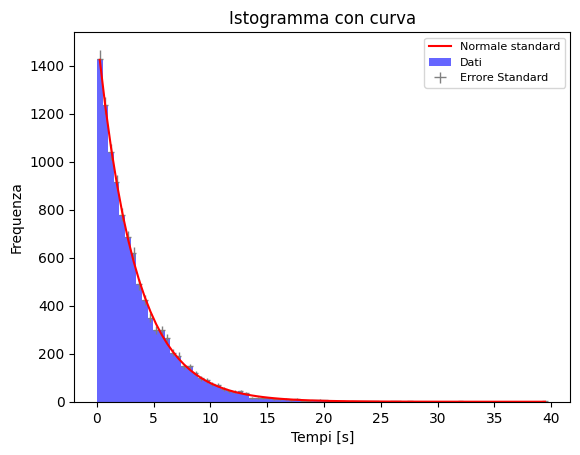

In [157]:
plot_poisson("Istogramma con curva", dati, stima_tau)

### LIKELIHOOD

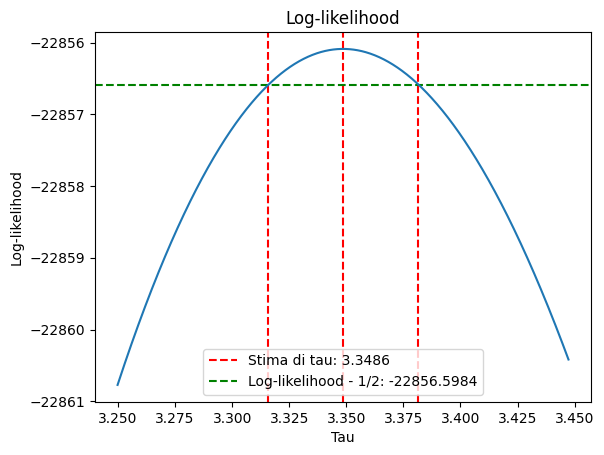

In [158]:
valori_tau = np.linspace(stima_tau-3*np.sqrt(var_tau), stima_tau + 3*np.sqrt(var_tau), 1000)
val_log_likelihood = [log_likelihood(dati, tau) for tau in valori_tau]  
plt.axvline(3.3487, color='red', linestyle='--', label=f'Stima di tau: {stima_tau:.4f}')
plt.axvline(3.3158, color='red', linestyle='--')
plt.axvline(3.3816, color='red', linestyle='--')
plt.axhline(-22856.0984 - 0.5, color='green', linestyle='--', label=f'Log-likelihood - 1/2: {-22856.0984 - 0.5:.4f}')
plt.plot(valori_tau, val_log_likelihood)
plt.title("Log-likelihood")
plt.xlabel("Tau")
plt.ylabel("Log-likelihood")
plt.legend()


#### MAX_LIKELIHOOD

In [159]:
for i in range(len(valori_tau)):
    if val_log_likelihood[i] > val_log_likelihood[i+1]:
        print(f"Massimo log-likelihood: {valori_tau[i]:.4f} con valore: {val_log_likelihood[i]:.4f}")
        max_log_likelihood = valori_tau[i]
        valore_max = val_log_likelihood[i]
        break
    else:
        continue



Massimo log-likelihood: 3.3487 con valore: -22856.0894


In [160]:
valori_tau_mezzo = []

likelihood_val = valore_max - 0.5
tolleranza = 0.01

for i in range(len(valori_tau)):
    if abs(val_log_likelihood[i] - likelihood_val) < tolleranza:
        print(f"valore vicino a log_likelihood -1/2: {valori_tau[i]:.4f}")
        valori_tau_mezzo.append(valori_tau[i])
        
    if len(valori_tau_mezzo) == 5:
        break

print(f"Valori di tau trovati: {valori_tau_mezzo}")

valori_tau_mezzo = [3.3158, 3.3816]


valore vicino a log_likelihood -1/2: 3.3156
valore vicino a log_likelihood -1/2: 3.3158
valore vicino a log_likelihood -1/2: 3.3160
valore vicino a log_likelihood -1/2: 3.3815
valore vicino a log_likelihood -1/2: 3.3817
Valori di tau trovati: [np.float64(3.3156464975779865), np.float64(3.3158441922655615), np.float64(3.3160418869531365), np.float64(3.3814788285404798), np.float64(3.381676523228055)]


### CALCOLO NUOVA STIMA

In [161]:
nuova_stima = valori_tau_mezzo[0] + np.sqrt(var_tau)
print(f"Nuova stima di tau: {nuova_stima:.4f}")

Nuova stima di tau: 3.3487


### SIMULO L'ESPERIMENTO

Media delle stime: 3.3486
Varianza delle stime: 0.0012
Varianza precedente: 0.0011


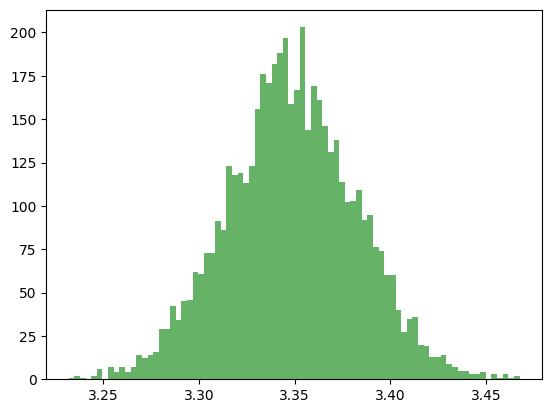

In [162]:
N=len(dati)
m=5000
valori_stime = []
for i in range(m):
    u= np.random.uniform(0,1,N)
    e = -nuova_stima*np.log(1-u)
    stima_tau=np.sum(e)/N
    valori_stime.append(stima_tau)

n, bins, patches = plt.hist(valori_stime, bins=80, density=False, alpha=0.6, color='g')
delta_x = bins[1] - bins[0]
centri = (bins[:-1] + bins[1:]) / 2
media=np.mean(valori_stime)
var_media=np.sum((valori_stime - media)**2)/len(valori_stime)
print(f"Media delle stime: {media:.4f}")
print(f"Varianza delle stime: {var_media:.4f}")
print(f"Varianza precedente: {var_tau:.4f}")




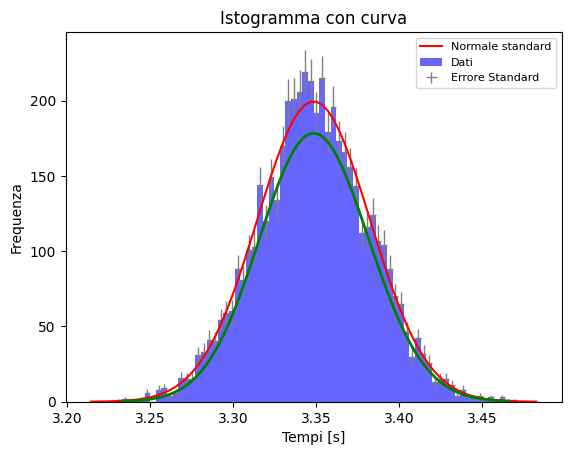

In [ ]:
plot_gaussiana("Istogramma con curva", valori_stime, media, var_media)
grafico = (np.exp(log_likelihood(dati, centri)  - log_likelihood_normal(len(dati), dati))) * len(valori_stime) * delta_x
plt.plot(centri, grafico, color='green', lw=2, label='Likelihood Teorica Normalizzata')
plt.show()